In [8]:
from pathlib import Path
import sys

# phase_9.ipynb is inside Market Risk/notebooks/
ROOT = Path.cwd().parent

# If notebook is already running from Market Risk root,
# don't move up again.
if ROOT.name.lower() != "market risk":
    ROOT = Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("PROJECT ROOT:")
print(ROOT)

print("\nRISK DIRECTORY:")
print(ROOT / "data" / "risk")

PROJECT ROOT:
c:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk

RISK DIRECTORY:
c:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\risk


In [9]:
risk_dir = ROOT / "data" / "risk"

print("Risk directory:")
print(risk_dir)

print("\nDoes risk directory exist?")
print(risk_dir.exists())

if risk_dir.exists():
    print("\nFiles currently inside data/risk:")
    for file in risk_dir.iterdir():
        print(file.name)

Risk directory:
c:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\risk

Does risk directory exist?
True

Files currently inside data/risk:
backtest_observations.csv
backtest_results.csv
ewma_scaled_returns.csv
ewma_var.csv
ewma_volatility.csv
historical_var_es.csv
phase9_backtesting_summary.csv
phase9_model_comparison.csv
phase9_model_ranking.csv
phase9_observations.csv
rolling_var.csv


In [10]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent

if not (ROOT / "data").exists():
    raise FileNotFoundError(
        f"Could not identify Market Risk project root.\n"
        f"Current ROOT: {ROOT}"
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

risk_dir = ROOT / "data" / "risk"

print("ROOT:", ROOT)
print("RISK:", risk_dir)

ROOT: c:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk
RISK: c:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\risk


In [11]:
import pandas as pd
import numpy as np

from src.risk.model_comparison import (
    compare_models,
    build_observation_dataset,
    rank_models,
)

In [12]:
risk_dir = ROOT / "data" / "risk"

comparison = pd.read_csv(
    risk_dir / "phase9_model_comparison.csv"
)

observations = pd.read_csv(
    risk_dir / "phase9_observations.csv"
)

ranking = pd.read_csv(
    risk_dir / "phase9_model_ranking.csv"
)

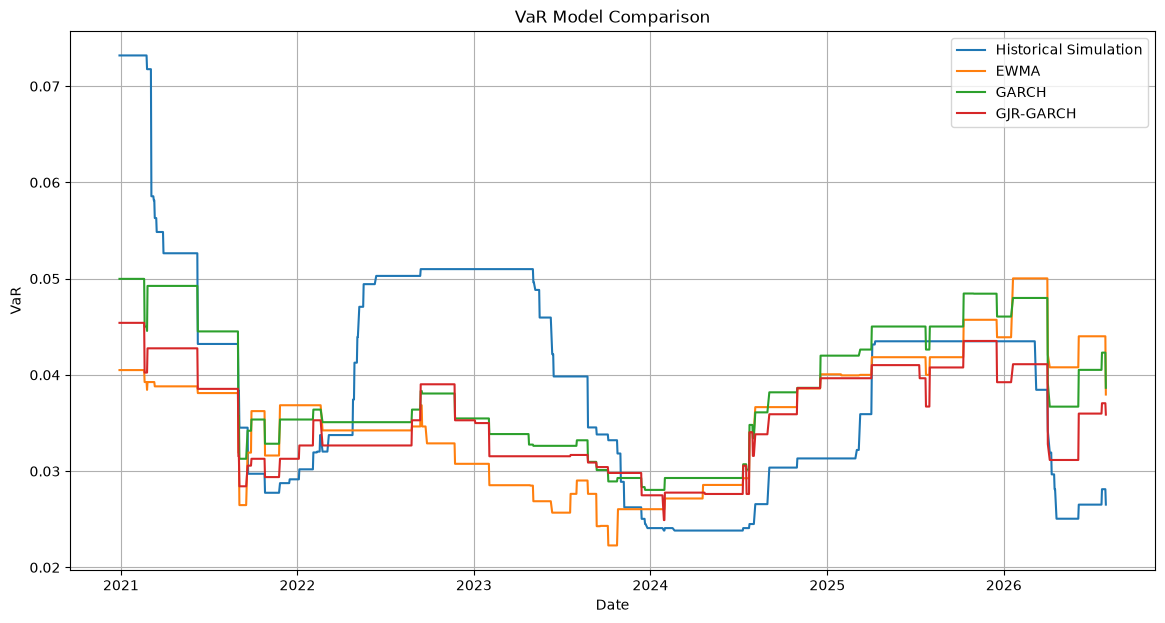

In [13]:
import matplotlib.pyplot as plt

observations["Date"] = pd.to_datetime(
    observations["Date"]
)

plt.figure(figsize=(14, 7))

plt.plot(
    observations["Date"],
    observations["Historical VaR"],
    label="Historical Simulation",
)

plt.plot(
    observations["Date"],
    observations["EWMA VaR"],
    label="EWMA",
)

plt.plot(
    observations["Date"],
    observations["GARCH VaR"],
    label="GARCH",
)

plt.plot(
    observations["Date"],
    observations["GJR-GARCH VaR"],
    label="GJR-GARCH",
)

plt.title("VaR Model Comparison")
plt.xlabel("Date")
plt.ylabel("VaR")
plt.legend()
plt.grid(True)

plt.show()

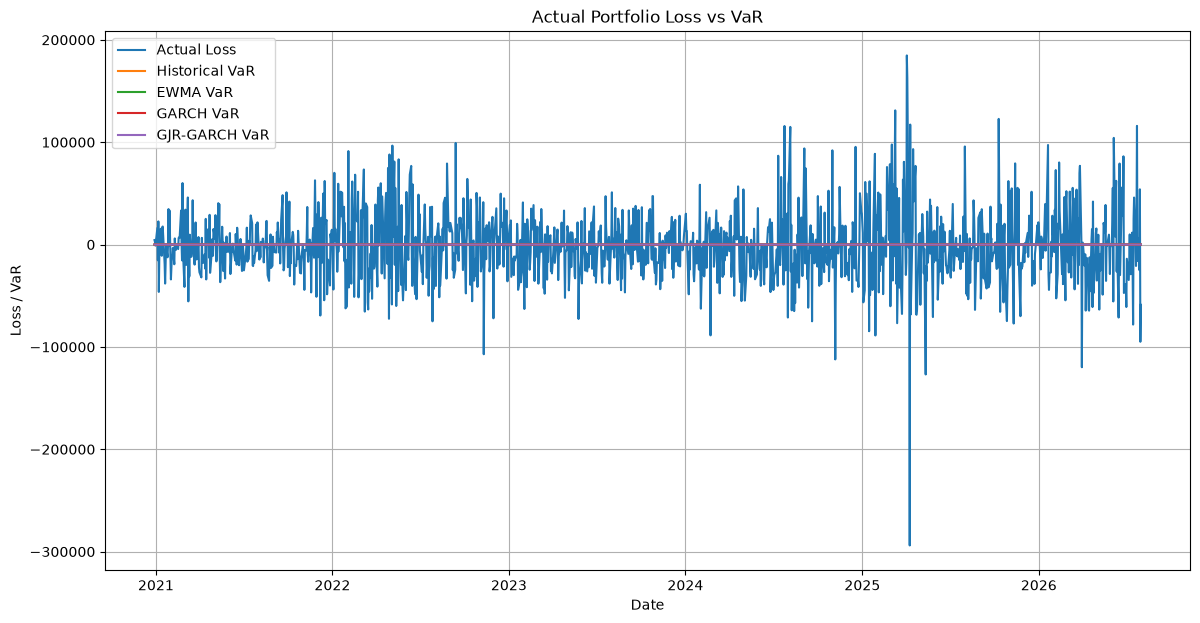

In [14]:
plt.figure(figsize=(14, 7))

plt.plot(
    observations["Date"],
    -observations["Portfolio P&L"],
    label="Actual Loss",
)

plt.plot(
    observations["Date"],
    observations["Historical VaR"],
    label="Historical VaR",
)

plt.plot(
    observations["Date"],
    observations["EWMA VaR"],
    label="EWMA VaR",
)

plt.plot(
    observations["Date"],
    observations["GARCH VaR"],
    label="GARCH VaR",
)

plt.plot(
    observations["Date"],
    observations["GJR-GARCH VaR"],
    label="GJR-GARCH VaR",
)

plt.title("Actual Portfolio Loss vs VaR")
plt.xlabel("Date")
plt.ylabel("Loss / VaR")
plt.legend()
plt.grid(True)

plt.show()

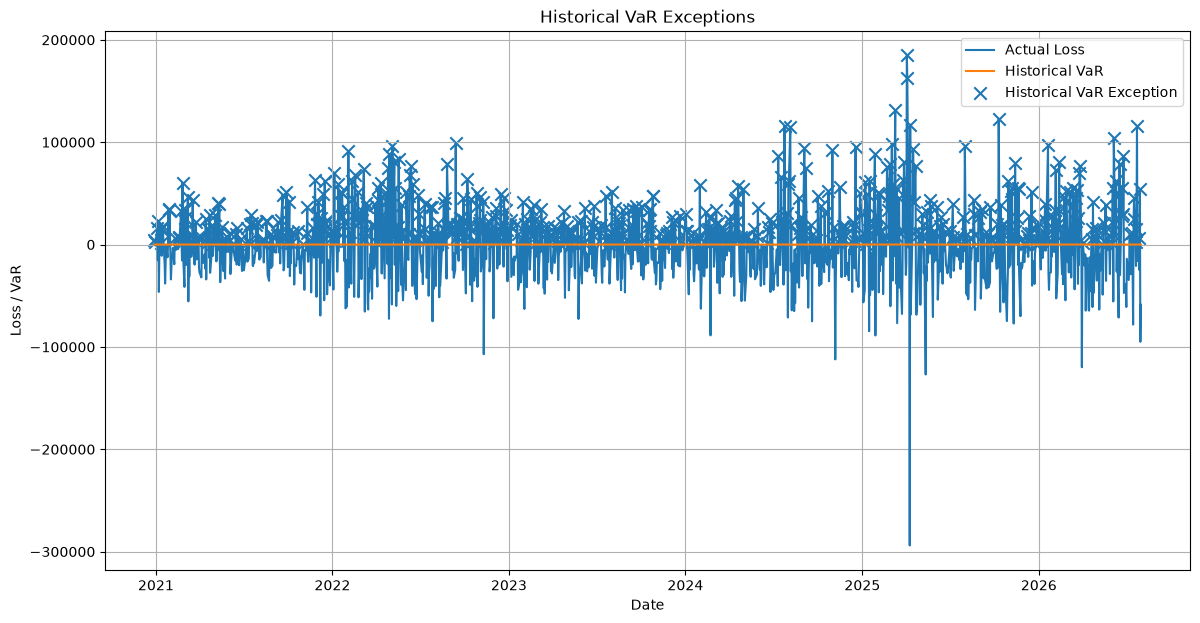

In [15]:
plt.figure(figsize=(14, 7))

plt.plot(
    observations["Date"],
    -observations["Portfolio P&L"],
    label="Actual Loss",
)

plt.plot(
    observations["Date"],
    observations["Historical VaR"],
    label="Historical VaR",
)

exceptions = observations[
    observations["Historical Simulation Exception"] == 1
]

plt.scatter(
    exceptions["Date"],
    -exceptions["Portfolio P&L"],
    marker="x",
    s=80,
    label="Historical VaR Exception",
)

plt.title(
    "Historical VaR Exceptions"
)

plt.xlabel("Date")
plt.ylabel("Loss / VaR")
plt.legend()
plt.grid(True)

plt.show()

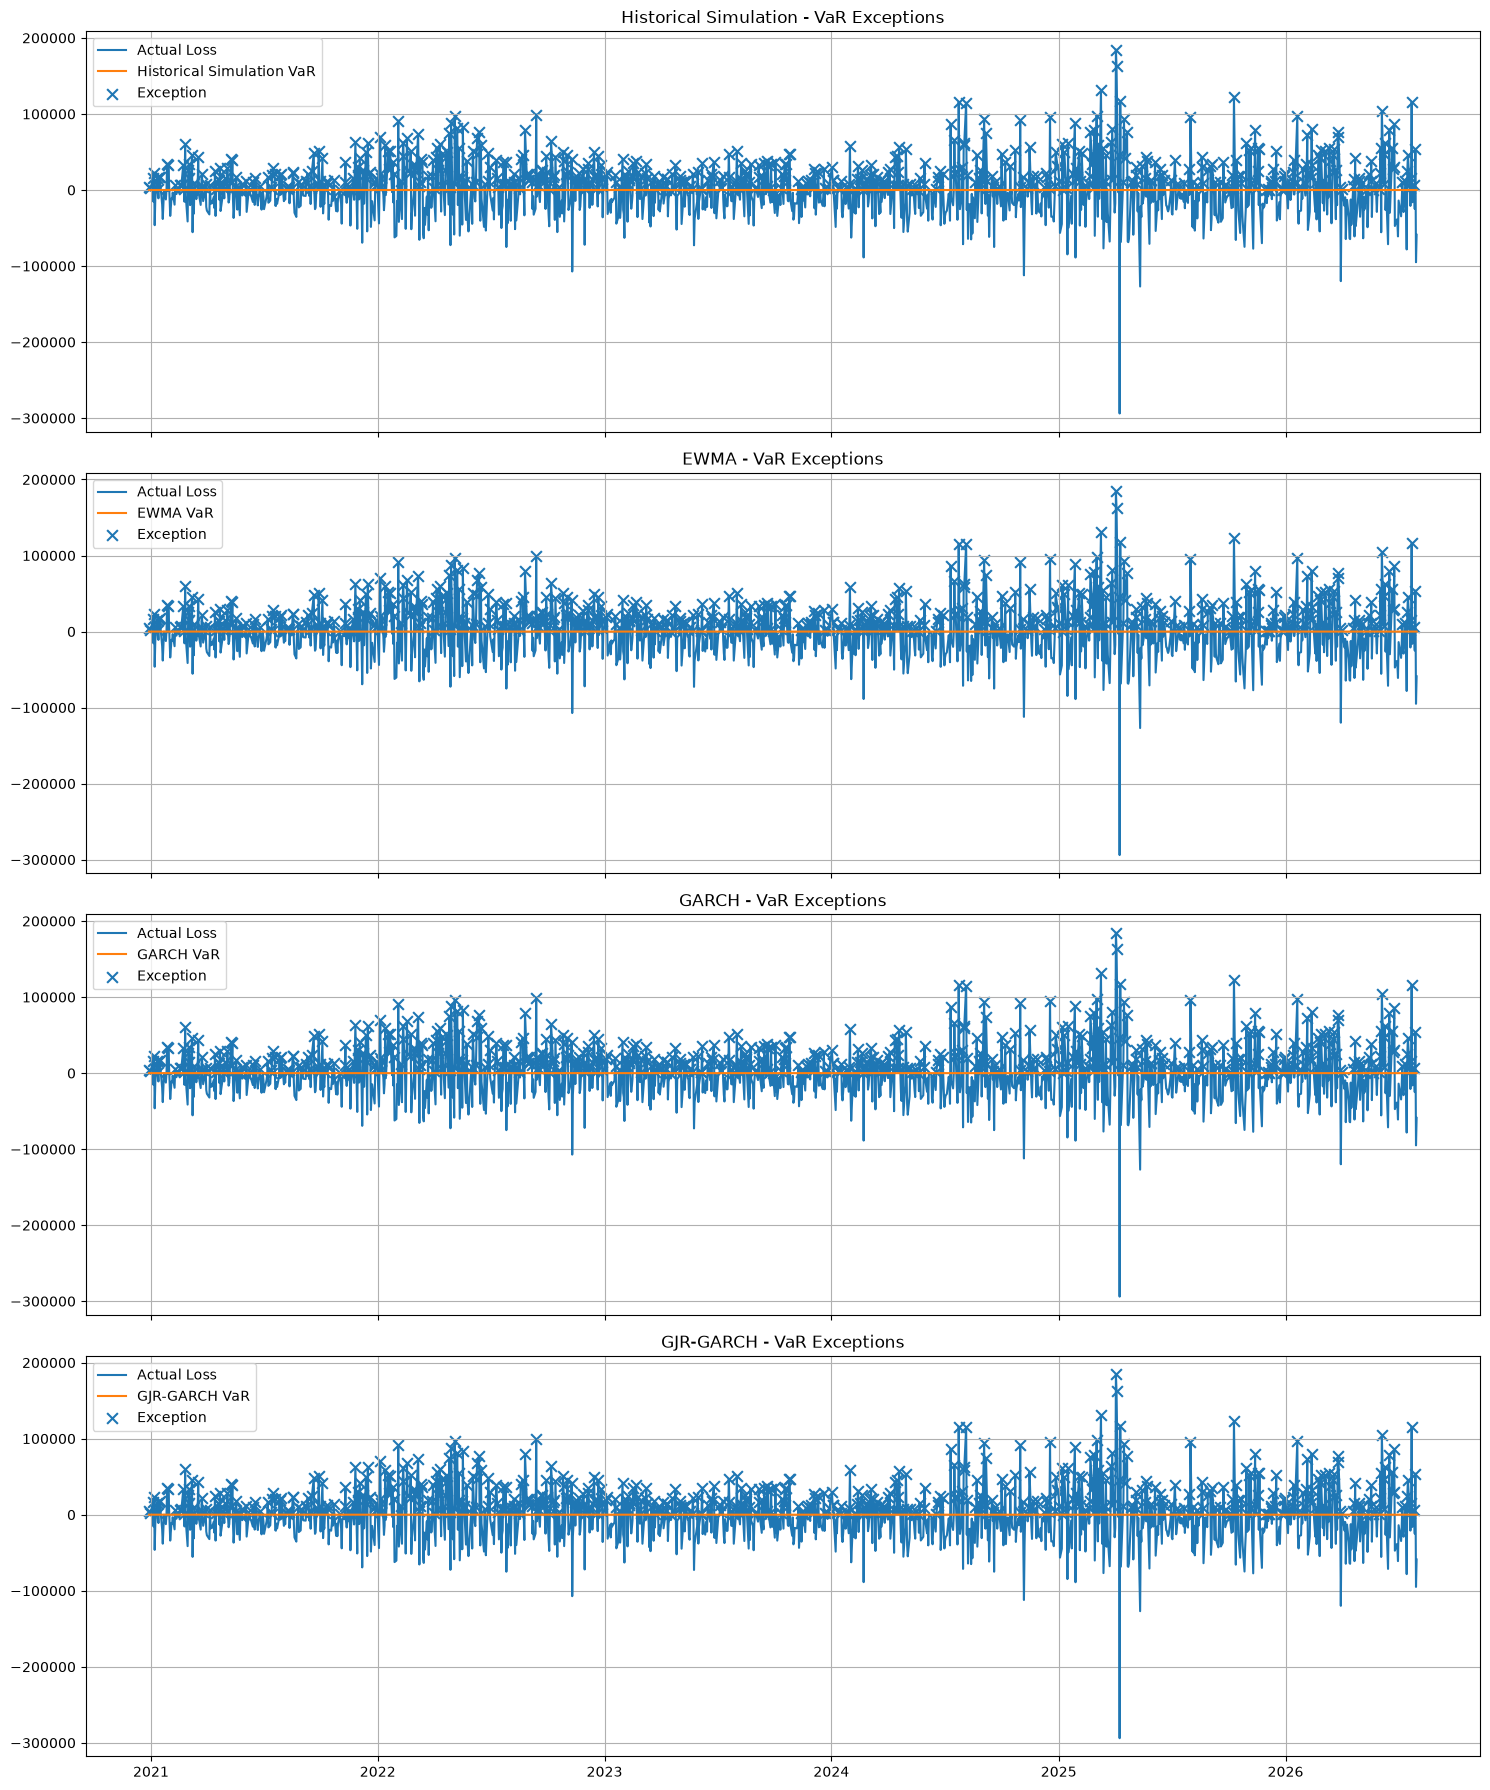

In [16]:
models = {
    "Historical Simulation": (
        "Historical VaR",
        "Historical Simulation Exception",
    ),
    "EWMA": (
        "EWMA VaR",
        "EWMA Exception",
    ),
    "GARCH": (
        "GARCH VaR",
        "GARCH Exception",
    ),
    "GJR-GARCH": (
        "GJR-GARCH VaR",
        "GJR-GARCH Exception",
    ),
}

fig, axes = plt.subplots(
    4,
    1,
    figsize=(15, 18),
    sharex=True,
)

for ax, (model, (var_col, exception_col)) in zip(
    axes,
    models.items(),
):

    ax.plot(
        observations["Date"],
        -observations["Portfolio P&L"],
        label="Actual Loss",
    )

    ax.plot(
        observations["Date"],
        observations[var_col],
        label=f"{model} VaR",
    )

    exceptions = observations[
        observations[exception_col] == 1
    ]

    ax.scatter(
        exceptions["Date"],
        -exceptions["Portfolio P&L"],
        marker="x",
        s=60,
        label="Exception",
    )

    ax.set_title(
        f"{model} - VaR Exceptions"
    )

    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

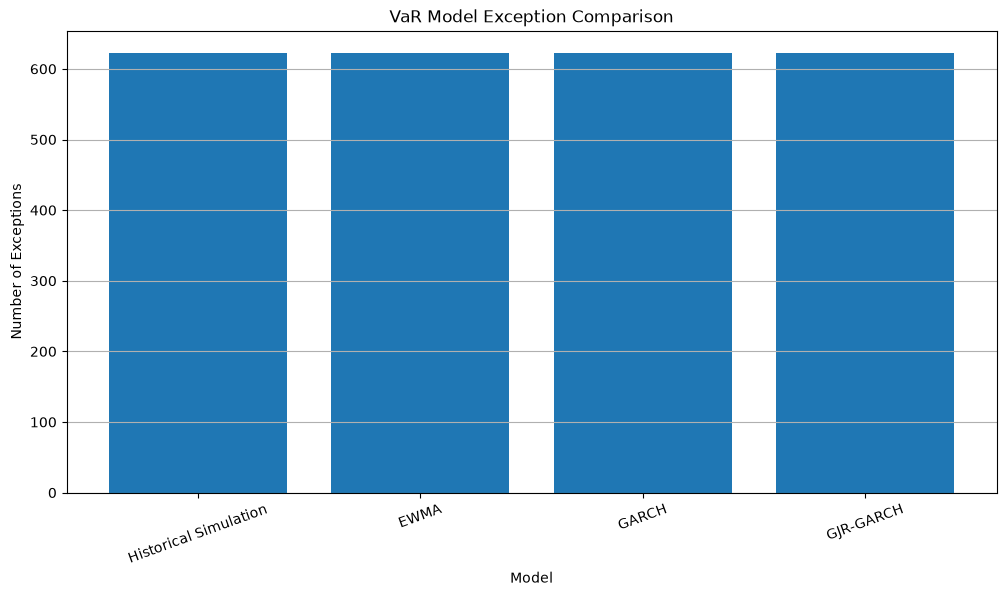

In [17]:
plt.figure(figsize=(12, 6))

plt.bar(
    comparison["Model"],
    comparison["Number of Exceptions"],
)

plt.title(
    "VaR Model Exception Comparison"
)

plt.xlabel("Model")
plt.ylabel("Number of Exceptions")

plt.xticks(rotation=20)

plt.grid(
    axis="y"
)

plt.show()

In [18]:
ranking[
    [
        "Overall Rank",
        "Model",
        "Number of Exceptions",
        "Exception Ratio",
        "Average VaR",
        "VaR Volatility",
        "Expected Shortfall",
        "Kupiec p-value",
        "Traffic Light",
        "Score",
    ]
]

,Overall Rank,Model,Number of Exceptions,Exception Ratio,Average VaR,VaR Volatility,Expected Shortfall,Kupiec p-value,Traffic Light,Score
0,1,GJR-GARCH,623,0.444048,0.035382,0.005117,25610.397326,0.0,Red,5.0
1,2,EWMA,623,0.444048,0.035600,0.006545,25610.397326,0.0,Red,7.0
2,3,GARCH,623,0.444048,0.038323,0.006550,25610.397326,0.0,Red,9.0
3,4,Historical Simulation,623,0.444048,0.039172,0.011480,25610.397326,0.0,Red,11.0
